In [15]:
import numpy as np 
import pandas as pd 
import os
import torch
from torch.utils.data import Dataset, DataLoader
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import random_split
from torchvision import transforms
import copy


In [16]:
def make_gaussian_heatmap(size, center, sigma=2):
    x = np.arange(0, size[1], 1, np.float32)
    y = np.arange(0, size[0], 1, np.float32)
    y = y[:, np.newaxis]

    x0, y0 = center
    heatmap = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
    return heatmap

In [17]:
class CornerDataset(Dataset):
    def __init__(self, annotations, image_dir, heatmap_size=56, sigma=2):
        with open(annotations, 'r') as f:
            data = json.load(f)
            all_image_annotations = data["images"]
            corners_list = data["annotations"]["corners"]
        
        self.image_dir = image_dir
        self.corners_annotations = {
            corner['image_id']: corner['corners'] for corner in corners_list
        }
        
        self.image_annotations = []
        for item in all_image_annotations:
            img_path = os.path.join(image_dir, item["path"])
            if os.path.isfile(img_path) and item["id"] in self.corners_annotations:
                self.image_annotations.append(item)

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
        
        self.heatmap_size = heatmap_size
        self.sigma = sigma

    def __len__(self):
        return len(self.image_annotations)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_annotations[idx]['path'])
        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size
        image = self.transform(image)
        
        img_id = self.image_annotations[idx]['id']
        corners_dict = self.corners_annotations[img_id]
        ordered_keys = ['top_left', 'top_right', 'bottom_right', 'bottom_left']
        corners = [corners_dict[key] for key in ordered_keys]

        normalized_corners = [
            [x / original_width, y / original_height] for (x, y) in corners
        ]
        
        heatmaps = []
        for (x_norm, y_norm) in normalized_corners:
            x_hm = x_norm * self.heatmap_size
            y_hm = y_norm * self.heatmap_size
            heatmap = make_gaussian_heatmap(
                (self.heatmap_size, self.heatmap_size),
                (x_hm, y_hm),
                sigma=self.sigma
            )
            heatmaps.append(heatmap)

        heatmaps = np.stack(heatmaps)  
        heatmaps = torch.tensor(heatmaps, dtype=torch.float32)
        
        return image, heatmaps


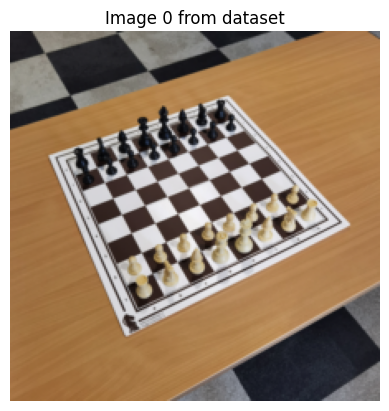

In [18]:
dataset = CornerDataset("/kaggle/input/dataset/dataset/annotations.json", "/kaggle/input/dataset/dataset/chessred2k/")
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=lambda x: x, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size, collate_fn=lambda x: x, num_workers=4, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size, collate_fn=lambda x: x, num_workers=4, pin_memory=True)


# Get the first item
image, heatmaps = dataset[0]

# The image tensor is in (C, H, W), so we need to permute it to (H, W, C) for displaying
image_np = image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.title("Image 0 from dataset")
plt.axis('off')
plt.show()

In [ ]:
class ResNetHeatmap(nn.Module):
    def __init__(self, backbone='resnet34', num_corners=4, heatmap_size=56):
        super(ResNetHeatmap, self).__init__()
        
        resnet = models.resnet34(weights='DEFAULT')
        self.features = nn.Sequential(*list(resnet.children())[:-2])  
        
        self.head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(128, num_corners, 2, stride=2)       
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetHeatmap().to(device)

In [ ]:
def one_epoch(model, optimizer, dataloader, loss_fn, is_training):
    model.train() if is_training else model.eval()
    avg_loss = 0.0

    for batch in dataloader:
        images = torch.stack([b[0] for b in batch]).to(device)
        targets = torch.stack([b[1] for b in batch]).to(device)

        with torch.set_grad_enabled(is_training):
            preds = model(images)  
            loss = loss_fn(preds, targets)  
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        avg_loss += loss.item() / len(dataloader)
    return avg_loss


In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss = one_epoch(model, optimizer, train_dataloader, criterion, is_training=True)
    val_loss = one_epoch(model, optimizer, val_dataloader, criterion, is_training=False)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")    

    if val_loss < best_val_metric:
        best_val_metric = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

In [ ]:
for param in model.features.parameters():
    param.requires_grad = True
    
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss = one_epoch(model, optimizer, train_dataloader, criterion, is_training=True)
    val_loss = one_epoch(model, optimizer, val_dataloader, criterion, is_training=False)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    # Early stopping
    
    if val_loss < best_val_metric:
        best_val_metric = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break
    else:
        print(epoch-best_epoch)

model.load_state_dict(best_model_state)

In [ ]:
torch.save(model.state_dict(), '/kaggle/working/my_model.pth')
print("saving model")

def heatmaps_to_points(heatmaps):
    num_corners, H, W = heatmaps.shape
    points = []

    for i in range(num_corners):
        heatmap = heatmaps[i]
        # Flatten and find argmax index
        max_val, idx = torch.max(heatmap.view(-1), dim=0)
        y, x = divmod(idx.item(), W)
        points.append((x, y))
    
    return points

def points_to_image_coordinates(points, heatmap_size, image_size=(224, 224)):
    img_w, img_h = image_size
    scale_x = img_w / heatmap_size
    scale_y = img_h / heatmap_size
    
    image_points = [
        (x * scale_x, y * scale_y) for (x, y) in points
    ]
    
    return image_points

def visualize_predictions(model, dataset, num_samples=5, image_size=224, heatmap_size=56):
    model.eval()
    
    total_distance = 0.0
    total_points = 0
    
    for i in range(num_samples):
        image, gt_heatmaps = dataset[i]
        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_heatmaps = model(input_image).cpu().squeeze(0)

        pred_points_hm = heatmaps_to_points(pred_heatmaps)
        pred_points_img = points_to_image_coordinates(pred_points_hm, heatmap_size, (image_size, image_size))

        gt_points_hm = heatmaps_to_points(gt_heatmaps)
        gt_points_img = points_to_image_coordinates(gt_points_hm, heatmap_size, (image_size, image_size))

        distances = []
        for pred_pt, gt_pt in zip(pred_points_img, gt_points_img):
            dist = np.linalg.norm(np.array(pred_pt) - np.array(gt_pt))
            distances.append(dist)
        
        total_distance += sum(distances)
        total_points += len(distances)

        image_np = image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(image_np)

        gt_points_np = np.array(gt_points_img)
        ax.plot(gt_points_np[:, 0], gt_points_np[:, 1], 'go-', label='Ground Truth')

        pred_points_np = np.array(pred_points_img)
        ax.plot(pred_points_np[:, 0], pred_points_np[:, 1], 'ro-', label='Prediction')

        for j, txt in enumerate(['TL', 'TR', 'BR', 'BL']):
            ax.annotate(txt, (gt_points_np[j][0], gt_points_np[j][1]), color='green')
            ax.annotate(txt, (pred_points_np[j][0], pred_points_np[j][1]), color='red')

        ax.legend()
        ax.set_title(f"Sample {i+1} - Avg Dist: {np.mean(distances):.2f} px")
        plt.show()
    
    average_distance = total_distance / total_points if total_points > 0 else 0.0
    print(f"\nOverall Average Distance: {average_distance:.2f} px")
    
    return average_distance


average_dist = visualize_predictions(model, test_dataloader.dataset, num_samples=len(test_dataloader.dataset))
print(f"Average point distance to ground truth: {average_dist:.2f} px")



Loading saved model...
The predicted points were 
 [(188.0, 96.0), (156.0, 164.0), (32.0, 128.0), (92.0, 76.0)]
The gt points were 
 [(188.0, 96.0), (156.0, 164.0), (36.0, 128.0), (92.0, 76.0)]


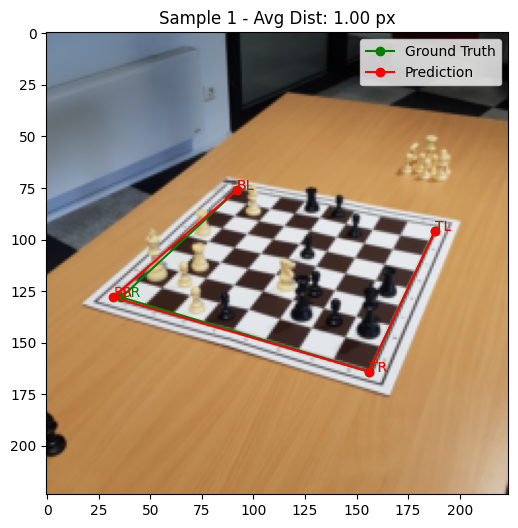

The predicted points were 
 [(188.0, 156.0), (40.0, 160.0), (56.0, 84.0), (168.0, 80.0)]
The gt points were 
 [(188.0, 156.0), (40.0, 160.0), (56.0, 84.0), (164.0, 80.0)]


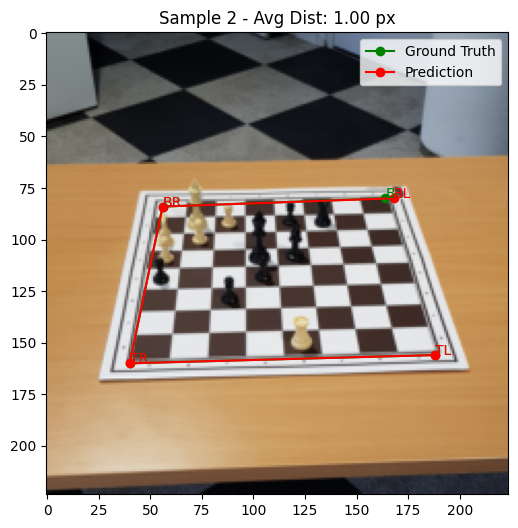

The predicted points were 
 [(172.0, 160.0), (40.0, 124.0), (88.0, 44.0), (192.0, 64.0)]
The gt points were 
 [(172.0, 156.0), (40.0, 124.0), (88.0, 44.0), (192.0, 64.0)]


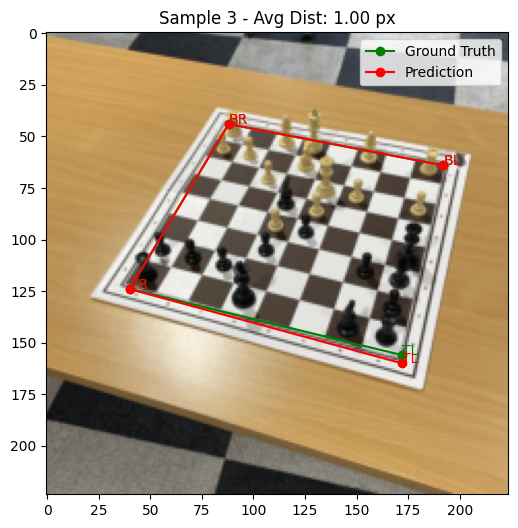


Overall Average Distance: 1.00 px
Average point distance to ground truth: 1.00 px


In [21]:
import os

def visualize_predictions(model, dataset, num_samples=5, image_size=224, heatmap_size=56):
    model.eval()
    
    total_distance = 0.0
    total_points = 0
    
    for i in range(num_samples):
        image, gt_heatmaps = dataset[i]
        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_heatmaps = model(input_image).cpu().squeeze(0)

        pred_points_hm = heatmaps_to_points(pred_heatmaps)
        pred_points_img = points_to_image_coordinates(pred_points_hm, heatmap_size, (image_size, image_size))
    
        print("The predicted points were \n", pred_points_img)    
        gt_points_hm = heatmaps_to_points(gt_heatmaps)
        gt_points_img = points_to_image_coordinates(gt_points_hm, heatmap_size, (image_size, image_size))
        print("The gt points were \n", gt_points_img)    

        distances = []
        for pred_pt, gt_pt in zip(pred_points_img, gt_points_img):
            dist = np.linalg.norm(np.array(pred_pt) - np.array(gt_pt))
            distances.append(dist)
        
        total_distance += sum(distances)
        total_points += len(distances)

        image_np = image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(image_np)

        gt_points_np = np.array(gt_points_img)
        ax.plot(gt_points_np[:, 0], gt_points_np[:, 1], 'go-', label='Ground Truth')

        pred_points_np = np.array(pred_points_img)
        ax.plot(pred_points_np[:, 0], pred_points_np[:, 1], 'ro-', label='Prediction')

        for j, txt in enumerate(['TL', 'TR', 'BR', 'BL']):
            ax.annotate(txt, (gt_points_np[j][0], gt_points_np[j][1]), color='green')
            ax.annotate(txt, (pred_points_np[j][0], pred_points_np[j][1]), color='red')

        ax.legend()
        ax.set_title(f"Sample {i+1} - Avg Dist: {np.mean(distances):.2f} px")
        plt.show()
    
    average_distance = total_distance / total_points if total_points > 0 else 0.0
    print(f"\nOverall Average Distance: {average_distance:.2f} px")
    
    return average_distance




if os.path.exists('my_model.pth'):
    print("Loading saved model...")
    model.load_state_dict(torch.load('my_model.pth'))
    average_dist = visualize_predictions(model, test_dataloader.dataset, num_samples=3)
    print(f"Average point distance to ground truth: {average_dist:.2f} px")

else:
    print("Training model...")
